# CDFS checking the seeing FWHM

In [6]:
import pandas as pd
import numpy as np

cat = pd.read_csv("/Users/aishwarya/Desktop/new_cdfs/cat_matched/LBG_I_CDFS_depth_decam_matched.cat")

print(cat.columns)


Index(['NUMBER', 'X_IMAGE', 'Y_IMAGE', 'ALPHA_J2000', 'DELTA_J2000',
       'MAG_APER', 'MAGERR_APER', 'MAG_AUTO', 'MAGERR_AUTO', 'FLAGS',
       'RA_CORRECTED', 'DEC_CORRECTED'],
      dtype='object')


# I band

/var/folders/9v/db3j63px68q3f33kdb7_7wbc0000gn/T/ipykernel_52434/1244418948.py:100: RuntimeWarning: invalid value encountered in sqrt
  fwhm = 2.0 * gamma * np.sqrt(2.0**(1.0/alpha) - 1.0)


Stars used        : 14006
Pixel scale       : 0.270 arcsec / pix
Median seeing     : 1.20 arcsec
Std (seeing)      : 0.15 arcsec


/Users/aishwarya/.local/share/mamba/envs/astroenv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


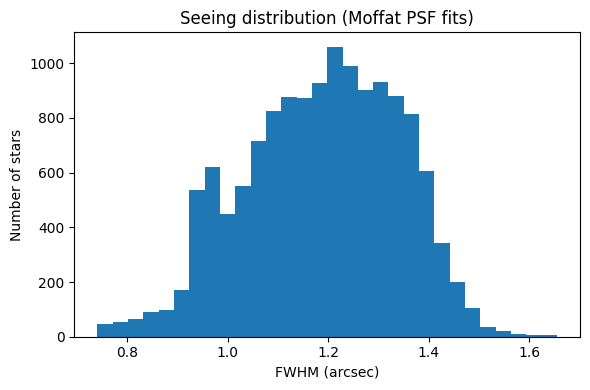

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.modeling import models, fitting
from astropy.stats import sigma_clip

# ============================================================
# File paths
# ============================================================
img_file = "/Users/aishwarya/Desktop/new_cdfs/trimmed_2deg/trim2deg_i_sci.fits"
cat_file = "/Users/aishwarya/Desktop/new_cdfs/cat_matched/LBG_I_CDFS_depth_decam_matched.cat"

# ============================================================
# Load image and WCS
# ============================================================
with fits.open(img_file) as hdu:
    data = hdu[0].data
    header = hdu[0].header

wcs = WCS(header)

# ============================================================
# Load star catalog
# ============================================================
dec = pd.read_csv(cat_file)

# Use correct SExtractor world-coordinate columns
ra  = dec["ALPHA_J2000"].values
dec_ = dec["DELTA_J2000"].values

# Clean stars
good = (dec["FLAGS"] == 0)
ra, dec_ = ra[good], dec_[good]

# ============================================================
# Convert RA/DEC -> pixel coordinates
# ============================================================
coords = SkyCoord(ra=ra*u.deg, dec=dec_*u.deg)
x, y = wcs.world_to_pixel(coords)

# ============================================================
# Fitting setup
# ============================================================
fitter = fitting.LevMarLSQFitter()

stamp_size = 15
half = stamp_size // 2

fwhm_pix = []

# ============================================================
# Loop over stars
# ============================================================
for xi, yi in zip(x, y):

    if not np.isfinite(xi) or not np.isfinite(yi):
        continue

    xi, yi = int(xi), int(yi)

    if (xi < half or yi < half or
        xi + half >= data.shape[1] or
        yi + half >= data.shape[0]):
        continue

    stamp = data[yi-half:yi+half, xi-half:xi+half]

    if not np.isfinite(stamp).all():
        continue

    # subtract local background
    stamp = stamp - np.nanmedian(stamp)

    yy, xx = np.mgrid[:stamp.shape[0], :stamp.shape[1]]

    # --------------------------------------------------------
    # Initial Moffat model (Astropy definition)
    # --------------------------------------------------------
    m_init = models.Moffat2D(
        amplitude=np.nanmax(stamp),
        x_0=half,
        y_0=half,
        gamma=2.5,   # pix
        alpha=2.5   # typical ground-based PSF
    )

    try:
        m = fitter(m_init, xx, yy, stamp)

        gamma = m.gamma.value
        alpha = m.alpha.value

        # Moffat FWHM (pixels)
        fwhm = 2.0 * gamma * np.sqrt(2.0**(1.0/alpha) - 1.0)

        # sanity cuts
        if 0.5 < fwhm < 20:
            fwhm_pix.append(fwhm)

    except Exception:
        continue

# ============================================================
# Sigma clipping
# ============================================================
fwhm_pix = np.array(fwhm_pix)
fwhm_pix = sigma_clip(fwhm_pix, sigma=3)

# ============================================================
# Pixel scale
# ============================================================
pixscale = proj_plane_pixel_scales(wcs)[0] * 3600.0  # arcsec / pix

# ============================================================
# Convert to arcsec
# ============================================================
fwhm_arcsec = fwhm_pix * pixscale

# ============================================================
# Results
# ============================================================
print("======================================")
print(f"Stars used        : {len(fwhm_arcsec)}")
print(f"Pixel scale       : {pixscale:.3f} arcsec / pix")
print(f"Median seeing     : {np.nanmedian(fwhm_arcsec):.2f} arcsec")
print(f"Std (seeing)      : {np.nanstd(fwhm_arcsec):.2f} arcsec")
print("======================================")

# ============================================================
# Plot distribution
# ============================================================
plt.figure(figsize=(6,4))
plt.hist(fwhm_arcsec, bins=30)
plt.xlabel("FWHM (arcsec)")
plt.ylabel("Number of stars")
plt.title("Seeing distribution (Moffat PSF fits)")
plt.tight_layout()
plt.show()


/var/folders/9v/db3j63px68q3f33kdb7_7wbc0000gn/T/ipykernel_52434/2032846573.py:95: RuntimeWarning: invalid value encountered in sqrt
  fwhm = 2.0 * gamma * np.sqrt(2.0**(1.0/alpha) - 1.0)
/Users/aishwarya/.local/share/mamba/envs/astroenv/lib/python3.11/site-packages/astropy/modeling/functional_models.py:3297: RuntimeWarning: overflow encountered in power
  return amplitude * (1 + rr_gg) ** (-alpha)
/Users/aishwarya/.local/share/mamba/envs/astroenv/lib/python3.11/site-packages/astropy/modeling/functional_models.py:3297: RuntimeWarning: overflow encountered in multiply
  return amplitude * (1 + rr_gg) ** (-alpha)


Stars used        : 43447
Pixel scale       : 0.270 arcsec / pix
Median seeing     : 1.20 arcsec
Std (seeing)      : 0.17 arcsec


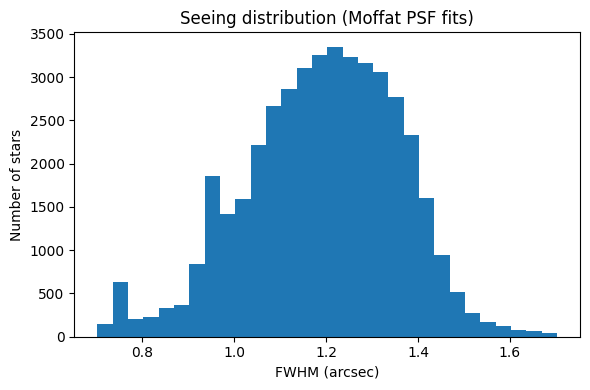

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.modeling import models, fitting
from astropy.stats import sigma_clip

# ============================================================
# File paths
# ============================================================
img_file = "/Users/aishwarya/Desktop/new_cdfs/trimmed_2deg/trim2deg_i_sci.fits"
cat_file = "/Users/aishwarya/Desktop/new_cdfs/cat_matched/LBG_I_CDFS_depth_panstarrs_matched.csv"

# ============================================================
# Load image and WCS
# ============================================================
with fits.open(img_file) as hdu:
    data = hdu[0].data
    header = hdu[0].header

wcs = WCS(header)

# ============================================================
# Load catalog
# ============================================================
df = pd.read_csv(cat_file)

ra_col  = "RA_CORRECTED"
dec_col = "DEC_CORRECTED"

df[ra_col]  = pd.to_numeric(df[ra_col], errors="coerce")
df[dec_col] = pd.to_numeric(df[dec_col], errors="coerce")

df = df.dropna(subset=[ra_col, dec_col])

ra  = df[ra_col].values
dec = df[dec_col].values

# ============================================================
# Convert RA/DEC -> pixel
# ============================================================
coords = SkyCoord(ra=ra*u.deg, dec=dec*u.deg)
x, y = wcs.world_to_pixel(coords)

# ============================================================
# Moffat fitting
# ============================================================
fitter = fitting.LevMarLSQFitter()

stamp_size = 15
half = stamp_size // 2

fwhm_pix = []

for xi, yi in zip(x, y):

    if not np.isfinite(xi) or not np.isfinite(yi):
        continue

    xi, yi = int(xi), int(yi)

    if (xi < half or yi < half or
        xi + half >= data.shape[1] or
        yi + half >= data.shape[0]):
        continue

    stamp = data[yi-half:yi+half, xi-half:xi+half]

    if not np.isfinite(stamp).all():
        continue

    stamp = stamp - np.nanmedian(stamp)

    yy, xx = np.mgrid[:stamp.shape[0], :stamp.shape[1]]

    m_init = models.Moffat2D(
        amplitude=np.nanmax(stamp),
        x_0=half,
        y_0=half,
        gamma=2.5,
        alpha=2.5
    )

    try:
        m = fitter(m_init, xx, yy, stamp)

        gamma = m.gamma.value
        alpha = m.alpha.value

        fwhm = 2.0 * gamma * np.sqrt(2.0**(1.0/alpha) - 1.0)

        if 0.5 < fwhm < 20:
            fwhm_pix.append(fwhm)

    except:
        continue

# ============================================================
# Sigma clipping
# ============================================================
fwhm_pix = np.array(fwhm_pix)
fwhm_pix = sigma_clip(fwhm_pix, sigma=3).compressed()

# ============================================================
# Pixel scale
# ============================================================
pixscale = proj_plane_pixel_scales(wcs)[0] * 3600.0

# ============================================================
# Convert to arcsec
# ============================================================
fwhm_arcsec = fwhm_pix * pixscale

# ============================================================
# Results
# ============================================================
print("======================================")
print(f"Stars used        : {len(fwhm_arcsec)}")
print(f"Pixel scale       : {pixscale:.3f} arcsec / pix")
print(f"Median seeing     : {np.median(fwhm_arcsec):.2f} arcsec")
print(f"Std (seeing)      : {np.std(fwhm_arcsec):.2f} arcsec")
print("======================================")

# ============================================================
# Plot
# ============================================================
plt.figure(figsize=(6,4))
plt.hist(fwhm_arcsec, bins=30)
plt.xlabel("FWHM (arcsec)")
plt.ylabel("Number of stars")
plt.title("Seeing distribution (Moffat PSF fits)")
plt.tight_layout()
plt.show()


# Z band 

/var/folders/9v/db3j63px68q3f33kdb7_7wbc0000gn/T/ipykernel_52434/3003419437.py:100: RuntimeWarning: invalid value encountered in sqrt
  fwhm = 2.0 * gamma * np.sqrt(2.0**(1.0/alpha) - 1.0)


Stars used        : 18599
Pixel scale       : 0.270 arcsec / pix
Median seeing     : 1.15 arcsec
Std (seeing)      : 0.17 arcsec


/Users/aishwarya/.local/share/mamba/envs/astroenv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


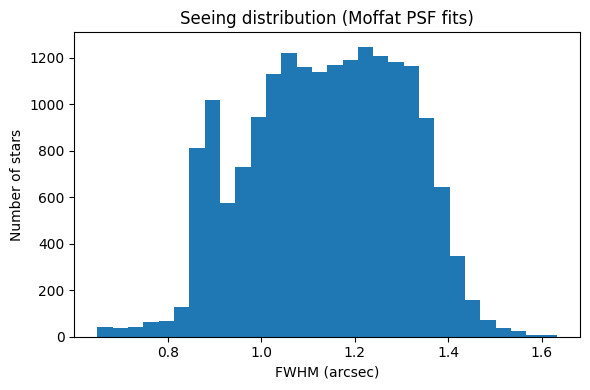

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.modeling import models, fitting
from astropy.stats import sigma_clip

# ============================================================
# File paths
# ============================================================
img_file = "/Users/aishwarya/Desktop/new_cdfs/trimmed_2deg/trim2deg_z_sci.fits"
cat_file = "//Users/aishwarya/Desktop/new_cdfs/cat_matched/LBG_Z_CDFS_depth_decam_matched.cat"

# ============================================================
# Load image and WCS
# ============================================================
with fits.open(img_file) as hdu:
    data = hdu[0].data
    header = hdu[0].header

wcs = WCS(header)

# ============================================================
# Load star catalog
# ============================================================
dec = pd.read_csv(cat_file)

# Use correct SExtractor world-coordinate columns
ra  = dec["ALPHA_J2000"].values
dec_ = dec["DELTA_J2000"].values

# Clean stars
good = (dec["FLAGS"] == 0)
ra, dec_ = ra[good], dec_[good]

# ============================================================
# Convert RA/DEC -> pixel coordinates
# ============================================================
coords = SkyCoord(ra=ra*u.deg, dec=dec_*u.deg)
x, y = wcs.world_to_pixel(coords)

# ============================================================
# Fitting setup
# ============================================================
fitter = fitting.LevMarLSQFitter()

stamp_size = 15
half = stamp_size // 2

fwhm_pix = []

# ============================================================
# Loop over stars
# ============================================================
for xi, yi in zip(x, y):

    if not np.isfinite(xi) or not np.isfinite(yi):
        continue

    xi, yi = int(xi), int(yi)

    if (xi < half or yi < half or
        xi + half >= data.shape[1] or
        yi + half >= data.shape[0]):
        continue

    stamp = data[yi-half:yi+half, xi-half:xi+half]

    if not np.isfinite(stamp).all():
        continue

    # subtract local background
    stamp = stamp - np.nanmedian(stamp)

    yy, xx = np.mgrid[:stamp.shape[0], :stamp.shape[1]]

    # --------------------------------------------------------
    # Initial Moffat model (Astropy definition)
    # --------------------------------------------------------
    m_init = models.Moffat2D(
        amplitude=np.nanmax(stamp),
        x_0=half,
        y_0=half,
        gamma=2.5,   # pix
        alpha=2.5   # typical ground-based PSF
    )

    try:
        m = fitter(m_init, xx, yy, stamp)

        gamma = m.gamma.value
        alpha = m.alpha.value

        # Moffat FWHM (pixels)
        fwhm = 2.0 * gamma * np.sqrt(2.0**(1.0/alpha) - 1.0)

        # sanity cuts
        if 0.5 < fwhm < 20:
            fwhm_pix.append(fwhm)

    except Exception:
        continue

# ============================================================
# Sigma clipping
# ============================================================
fwhm_pix = np.array(fwhm_pix)
fwhm_pix = sigma_clip(fwhm_pix, sigma=3)

# ============================================================
# Pixel scale
# ============================================================
pixscale = proj_plane_pixel_scales(wcs)[0] * 3600.0  # arcsec / pix

# ============================================================
# Convert to arcsec
# ============================================================
fwhm_arcsec = fwhm_pix * pixscale

# ============================================================
# Results
# ============================================================
print("======================================")
print(f"Stars used        : {len(fwhm_arcsec)}")
print(f"Pixel scale       : {pixscale:.3f} arcsec / pix")
print(f"Median seeing     : {np.nanmedian(fwhm_arcsec):.2f} arcsec")
print(f"Std (seeing)      : {np.nanstd(fwhm_arcsec):.2f} arcsec")
print("======================================")

# ============================================================
# Plot distribution
# ============================================================
plt.figure(figsize=(6,4))
plt.hist(fwhm_arcsec, bins=30)
plt.xlabel("FWHM (arcsec)")
plt.ylabel("Number of stars")
plt.title("Seeing distribution (Moffat PSF fits)")
plt.tight_layout()
plt.show()


# Y band

Stars used        : 69061
Pixel scale       : 0.270 arcsec / pix
Median seeing     : 0.96 arcsec
Std (seeing)      : 0.18 arcsec


/Users/aishwarya/.local/share/mamba/envs/astroenv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


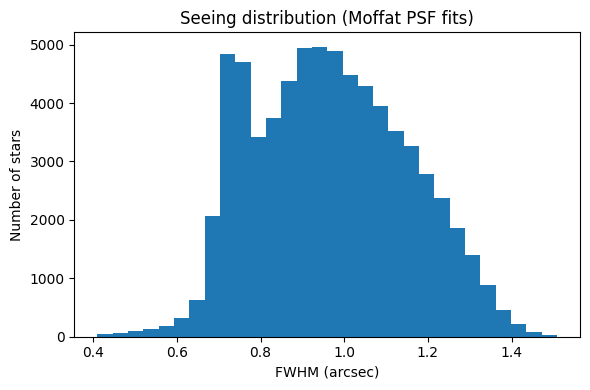

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.modeling import models, fitting
from astropy.stats import sigma_clip

# ============================================================
# File paths
# ============================================================
img_file = "/Users/aishwarya/Desktop/new_cdfs/trimmed_2deg/trim2deg_y_sci.fits"
cat_file = "/Users/aishwarya/Desktop/new_cdfs/cat_matched/LBG_Y_CDFS_depth_decam_matched.cat"

# ============================================================
# Load image and WCS
# ============================================================
with fits.open(img_file) as hdu:
    data = hdu[0].data
    header = hdu[0].header

wcs = WCS(header)

# ============================================================
# Load star catalog
# ============================================================
dec = pd.read_csv(cat_file)

# Use correct SExtractor world-coordinate columns
ra  = dec["ALPHA_J2000"].values
dec_ = dec["DELTA_J2000"].values

# Clean stars
good = (dec["FLAGS"] == 0)
ra, dec_ = ra[good], dec_[good]

# ============================================================
# Convert RA/DEC -> pixel coordinates
# ============================================================
coords = SkyCoord(ra=ra*u.deg, dec=dec_*u.deg)
x, y = wcs.world_to_pixel(coords)

# ============================================================
# Fitting setup
# ============================================================
fitter = fitting.LevMarLSQFitter()

stamp_size = 15
half = stamp_size // 2

fwhm_pix = []

# ============================================================
# Loop over stars
# ============================================================
for xi, yi in zip(x, y):

    if not np.isfinite(xi) or not np.isfinite(yi):
        continue

    xi, yi = int(xi), int(yi)

    if (xi < half or yi < half or
        xi + half >= data.shape[1] or
        yi + half >= data.shape[0]):
        continue

    stamp = data[yi-half:yi+half, xi-half:xi+half]

    if not np.isfinite(stamp).all():
        continue

    # subtract local background
    stamp = stamp - np.nanmedian(stamp)

    yy, xx = np.mgrid[:stamp.shape[0], :stamp.shape[1]]

    # --------------------------------------------------------
    # Initial Moffat model (Astropy definition)
    # --------------------------------------------------------
    m_init = models.Moffat2D(
        amplitude=np.nanmax(stamp),
        x_0=half,
        y_0=half,
        gamma=2.5,   # pix
        alpha=2.5   # typical ground-based PSF
    )

    try:
        m = fitter(m_init, xx, yy, stamp)

        gamma = m.gamma.value
        alpha = m.alpha.value

        # Moffat FWHM (pixels)
        fwhm = 2.0 * gamma * np.sqrt(2.0**(1.0/alpha) - 1.0)

        # sanity cuts
        if 0.5 < fwhm < 20:
            fwhm_pix.append(fwhm)

    except Exception:
        continue

# ============================================================
# Sigma clipping
# ============================================================
fwhm_pix = np.array(fwhm_pix)
fwhm_pix = sigma_clip(fwhm_pix, sigma=3)

# ============================================================
# Pixel scale
# ============================================================
pixscale = proj_plane_pixel_scales(wcs)[0] * 3600.0  # arcsec / pix

# ============================================================
# Convert to arcsec
# ============================================================
fwhm_arcsec = fwhm_pix * pixscale

# ============================================================
# Results
# ============================================================
print("======================================")
print(f"Stars used        : {len(fwhm_arcsec)}")
print(f"Pixel scale       : {pixscale:.3f} arcsec / pix")
print(f"Median seeing     : {np.nanmedian(fwhm_arcsec):.2f} arcsec")
print(f"Std (seeing)      : {np.nanstd(fwhm_arcsec):.2f} arcsec")
print("======================================")

# ============================================================
# Plot distribution
# ============================================================
plt.figure(figsize=(6,4))
plt.hist(fwhm_arcsec, bins=30)
plt.xlabel("FWHM (arcsec)")
plt.ylabel("Number of stars")
plt.title("Seeing distribution (Moffat PSF fits)")
plt.tight_layout()
plt.show()
